In [1]:
import random
import pandas as pd
import blosum
import copy
import time

blosum62 = blosum.BLOSUM(62)
NFE = 0
start_time = time.time()


In [2]:
def get_sequences():
    seq1 = "MGSSHHHHHHSSGLVPRGSHMASMTGGQQMGRDLYDDDDKDRWGKLVVLGAVTQGQKLVVLGAGGVGKSALTIQLIQNHFVDEYDPTIEDSYRKQVVIDGGGVGKSALTIQLIQNHFVDEYDPTIEDSYRKQV"
    seq2 = "MKTLLVAAAVVAGGQGQAEKLVKQLEQKAKELQKQLEQKAKELQKQLEQKAKELQKQLEQKAKELQKQLEQKAGVGKSALTIQLIQNHFVDEYDPTIEDSYRKQVVIDGETCLLDILDTAGQEEYSAMRDQKELQKQLGQKAKEL"
    seq3 = "MAVTQGQKLVVLGAGGVGKSALTIQLIQNHFVDEYDPTIEDSYRKQVVIDGETCLLDILDTAGQEEYSAMRDQYMRTGEGFAVVAGGQGQAEKLVKQLEQKAKELQKQLEQKAKELQKQLEQKAKELQKQLEQKAKELQKQLEQKALCVFAIN"
    return [list(seq1), list(seq2), list(seq3)]

def crear_individuo():
    return get_sequences()

def crear_poblacion_inicial(n=10):
    individuo_base = crear_individuo()
    poblacion = [ [row[:] for row in individuo_base] for _ in range(n) ]
    return poblacion

def mutar_poblacion_v2(poblacion, num_gaps=1):
    poblacion_mutada = []
    for individuo in poblacion:
        nuevo_individuo = []
        for fila in individuo:
            fila_mutada = fila[:]
            posiciones = set()
            for _ in range(num_gaps):
                pos = random.randint(0, len(fila_mutada))
                while pos in posiciones:
                    pos = random.randint(0, len(fila_mutada))
                posiciones.add(pos)
                fila_mutada.insert(pos, '-')
            nuevo_individuo.append(fila_mutada)
        poblacion_mutada.append(nuevo_individuo)
    return poblacion_mutada

def igualar_longitud_secuencias(individuo, gap='-'):
    max_len = max(len(fila) for fila in individuo)
    individuo_igualado = [fila + [gap]*(max_len - len(fila)) for fila in individuo]
    return individuo_igualado


def evaluar_individuo_blosum62(individuo):
    global NFE
    NFE += 1
    score = 0
    n_seqs = len(individuo)
    seq_len = len(individuo[0])
    for col in range(seq_len):
        for i in range(n_seqs):
            for j in range(i+1, n_seqs):
                a = individuo[i][col]
                b = individuo[j][col]
                if a == '-' or b == '-':
                    score -= 4
                else:
                    score += blosum62[a][b]
                    
    return score

def eliminar_peores(poblacion, scores, porcentaje=0.5):
    idx_ordenados = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)
    n_seleccionados = int(len(poblacion) * porcentaje)
    
    ind_seleccionados = [poblacion[i] for i in idx_ordenados[:n_seleccionados]]
    scores_seleccionados = [scores[i] for i in idx_ordenados[:n_seleccionados]]
    
    return ind_seleccionados, scores_seleccionados

def cruzar_individuos_doble_punto(ind1, ind2):
    hijo1 = []
    hijo2 = []
    for seq1, seq2 in zip(ind1, ind2):
        aa_indices = [i for i, a in enumerate(seq1) if a != '-']
        if len(aa_indices) < 6:
            hijo1.append(seq1[:])
            hijo2.append(seq2[:])
            continue

        # Asegurar que el segmento tenga al menos 5 aminoácidos
        intentos = 0
        while True:
            p1, p2 = sorted(random.sample(aa_indices, 2))
            if p2 - p1 >= 5 or intentos > 10:
                break
            intentos += 1

        def cruza(seqA, seqB):
            aaA = [a for a in seqA if a != '-']
            aaB = [a for a in seqB if a != '-']
            nueva = aaA[:p1] + aaB[p1:p2] + aaA[p2:]
            resultado = []
            idx = 0
            for a in seqA:
                if a == '-':
                    resultado.append('-')
                else:
                    resultado.append(nueva[idx])
                    idx += 1
            return resultado

        nueva_seq1 = cruza(seq1, seq2)
        nueva_seq2 = cruza(seq2, seq1)

        hijo1.append(nueva_seq1)
        hijo2.append(nueva_seq2)

    hijo1 = mutar_individuo(hijo1, 1, 0.8)
    hijo2 = mutar_individuo(hijo2, 1, 0.8)
    return hijo1, hijo2


def mutar_individuo(individuo, n_gaps, p):
    """
    Mutar un solo individuo insertando n_gaps en posiciones aleatorias de sus secuencias con probabilidad p.
    individuo: lista de listas (secuencias)
    n_gaps: número de gaps a insertar por secuencia
    p: probabilidad de insertar gap en cada secuencia
    """
    nuevo_individuo = []
    for secuencia in individuo:
        sec = secuencia[:]
        if random.random() < p:
            posiciones = set()
            for _ in range(n_gaps):
                pos = random.randint(0, len(sec))
                while pos in posiciones:
                    pos = random.randint(0, len(sec))
                posiciones.add(pos)
                sec.insert(pos, '-')
        nuevo_individuo.append(sec)
    return nuevo_individuo

def cruzar_poblacion_doble_punto(poblacion):
    """
    Selecciona parejas aleatorias y realiza cruza de doble punto de corte ignorando gaps.
    Duplica el tamaño de la población.
    """
    nueva_poblacion = []
    n = len(poblacion)
    indices = list(range(n))
    random.shuffle(indices)
    parejas = [(indices[i], indices[i+1]) for i in range(0, n-1, 2)]
    if n % 2 == 1:
        parejas.append((indices[-1], indices[0]))
    for idx1, idx2 in parejas:
        padre1 = poblacion[idx1]
        padre2 = poblacion[idx2]
        hijo1, hijo2 = cruzar_individuos_doble_punto(padre1, padre2)
        
#         score_padre1 = evaluar_individuo_blosum62(padre1)
#         score_padre2 = evaluar_individuo_blosum62(padre2)
#         score_hijo1 = evaluar_individuo_blosum62(hijo1)
#         score_hijo2 = evaluar_individuo_blosum62(hijo2)

        #print(f"Padre1: {score_padre1}, Padre2: {score_padre2}, Hijo1: {score_hijo1}, Hijo2: {score_hijo2}")
        
        nueva_poblacion.append(copy.deepcopy(padre1))
        nueva_poblacion.append(copy.deepcopy(padre2))
        nueva_poblacion.append(hijo1)
        nueva_poblacion.append(hijo2)
    # Recortar si se excede el doble
    return nueva_poblacion[:2*n]

def validar_poblacion_sin_gaps(poblacion, originales):
    """
    Valida que, al eliminar los gaps de cada secuencia de cada individuo,
    las secuencias resultantes sean idénticas a las originales.
    Devuelve True si todas coinciden, False si alguna no.
    """
    for individuo in poblacion:
        for seq, seq_orig in zip(individuo, originales):
            seq_sin_gaps = [a for a in seq if a != '-']
            seq_orig_sin_gaps = [a for a in seq_orig if a != '-']
            if seq_sin_gaps != seq_orig_sin_gaps:
                return False
    return True





def obtener_best(scores, poblacion):
    idx_mejor = scores.index(max(scores))
    fitness_best = scores[idx_mejor]
    best = copy.deepcopy(poblacion[idx_mejor])
    return best, fitness_best

In [3]:
if __name__ == "__main__":
    veryBest = None
    fitnessVeryBest = None
    poblacion = crear_poblacion_inicial(10)
    poblacion = mutar_poblacion_v2(poblacion, num_gaps=1)
    poblacion = [igualar_longitud_secuencias(ind) for ind in poblacion]
    scores = [evaluar_individuo_blosum62(ind) for ind in poblacion]
    poblacion, scores = eliminar_peores(poblacion, scores)
    
    
    for generaciones in range(100):
        poblacion = cruzar_poblacion_doble_punto(poblacion)
        #poblacion = mutar_poblacion_v2(poblacion, num_gaps=1)
        poblacion = [igualar_longitud_secuencias(ind) for ind in poblacion]
        scores = [evaluar_individuo_blosum62(ind) for ind in poblacion]
        #print(scores)
        poblacion, scores = eliminar_peores(poblacion, scores)
        #print(scores)
        best, fitness_best = obtener_best(scores, poblacion)
        if veryBest is None or fitness_best>fitnessVeryBest:
            veryBest = best
            fitnessVeryBest = fitness_best
        end_time = time.time()
        transcurrido = end_time - start_time
        print("fitness: ", fitnessVeryBest, "NFE: ", NFE, "time: ", transcurrido )
    print(veryBest)
    print ("validacion de integridad: ",validar_poblacion_sin_gaps(poblacion, get_sequences()))
    

fitness:  -436.0 NFE:  20 time:  0.04248237609863281
fitness:  -436.0 NFE:  30 time:  0.04603290557861328
fitness:  -436.0 NFE:  40 time:  0.04864072799682617
fitness:  -436.0 NFE:  50 time:  0.05290102958679199
fitness:  -436.0 NFE:  60 time:  0.0559237003326416
fitness:  -436.0 NFE:  70 time:  0.058646440505981445
fitness:  -436.0 NFE:  80 time:  0.06159615516662598
fitness:  -436.0 NFE:  90 time:  0.0636758804321289
fitness:  -436.0 NFE:  100 time:  0.06858420372009277
fitness:  -436.0 NFE:  110 time:  0.07193112373352051
fitness:  -436.0 NFE:  120 time:  0.0755612850189209
fitness:  -436.0 NFE:  130 time:  0.07853507995605469
fitness:  -436.0 NFE:  140 time:  0.08319807052612305
fitness:  -436.0 NFE:  150 time:  0.08602571487426758
fitness:  -436.0 NFE:  160 time:  0.08896541595458984
fitness:  -436.0 NFE:  170 time:  0.09134125709533691
fitness:  -436.0 NFE:  180 time:  0.09475374221801758
fitness:  -431.0 NFE:  190 time:  0.09749126434326172
fitness:  -431.0 NFE:  200 time:  0.10

CODIGO MODIFICADO

In [4]:
import matplotlib.pyplot as plt

In [5]:
def cruzar_individuos_doble_punto(ind1, ind2, n_gaps_hijo=1, p_mutacion=0.8):
    hijo1 = []
    hijo2 = []

    for seq1, seq2 in zip(ind1, ind2):
        aa_indices = [i for i, a in enumerate(seq1) if a != '-']

        if len(aa_indices) < 6:
            hijo1.append(seq1[:])
            hijo2.append(seq2[:])
            continue

        intentos = 0
        while True:
            p1, p2 = sorted(random.sample(aa_indices, 2))
            if p2 - p1 >= 5 or intentos > 10:
                break
            intentos += 1

        def cruza(seqA, seqB):
            aaA = [a for a in seqA if a != '-']
            aaB = [a for a in seqB if a != '-']

            nueva = aaA[:p1] + aaB[p1:p2] + aaA[p2:]

            resultado = []
            idx = 0

            for a in seqA:
                if a == '-':
                    resultado.append('-')
                else:
                    resultado.append(nueva[idx])
                    idx += 1

            return resultado

        nueva_seq1 = cruza(seq1, seq2)
        nueva_seq2 = cruza(seq2, seq1)

        hijo1.append(nueva_seq1)
        hijo2.append(nueva_seq2)

    hijo1 = mutar_individuo(hijo1, n_gaps_hijo, p_mutacion)
    hijo2 = mutar_individuo(hijo2, n_gaps_hijo, p_mutacion)

    return hijo1, hijo2


def cruzar_poblacion_doble_punto(poblacion, p_cruce=1.0, n_gaps_hijo=1, p_mutacion=0.8):
    nueva_poblacion = []
    n = len(poblacion)

    indices = list(range(n))
    random.shuffle(indices)

    parejas = [(indices[i], indices[i+1]) for i in range(0, n-1, 2)]

    if n % 2 == 1:
        parejas.append((indices[-1], indices[0]))

    for idx1, idx2 in parejas:
        padre1 = poblacion[idx1]
        padre2 = poblacion[idx2]

        if random.random() < p_cruce:
            hijo1, hijo2 = cruzar_individuos_doble_punto(
                padre1,
                padre2,
                n_gaps_hijo=n_gaps_hijo,
                p_mutacion=p_mutacion
            )
        else:
            hijo1 = copy.deepcopy(padre1)
            hijo2 = copy.deepcopy(padre2)

        nueva_poblacion.append(copy.deepcopy(padre1))
        nueva_poblacion.append(copy.deepcopy(padre2))
        nueva_poblacion.append(hijo1)
        nueva_poblacion.append(hijo2)

    return nueva_poblacion[:2*n]

Original Generación: 1 Fitness: -422.0 NFE: 20 Tiempo: 0.0055
Original Generación: 2 Fitness: -422.0 NFE: 30 Tiempo: 0.0095
Original Generación: 3 Fitness: -422.0 NFE: 40 Tiempo: 0.0135
Original Generación: 4 Fitness: -422.0 NFE: 50 Tiempo: 0.0165
Original Generación: 5 Fitness: -422.0 NFE: 60 Tiempo: 0.02
Original Generación: 6 Fitness: -422.0 NFE: 70 Tiempo: 0.0236
Original Generación: 7 Fitness: -422.0 NFE: 80 Tiempo: 0.0266
Original Generación: 8 Fitness: -422.0 NFE: 90 Tiempo: 0.0286
Original Generación: 9 Fitness: -422.0 NFE: 100 Tiempo: 0.0328
Original Generación: 10 Fitness: -418.0 NFE: 110 Tiempo: 0.0358
Original Generación: 11 Fitness: -418.0 NFE: 120 Tiempo: 0.0388
Original Generación: 12 Fitness: -418.0 NFE: 130 Tiempo: 0.0413
Original Generación: 13 Fitness: -418.0 NFE: 140 Tiempo: 0.0444
Original Generación: 14 Fitness: -418.0 NFE: 150 Tiempo: 0.0473
Original Generación: 15 Fitness: -418.0 NFE: 160 Tiempo: 0.0503
Original Generación: 16 Fitness: -418.0 NFE: 170 Tiempo: 0.

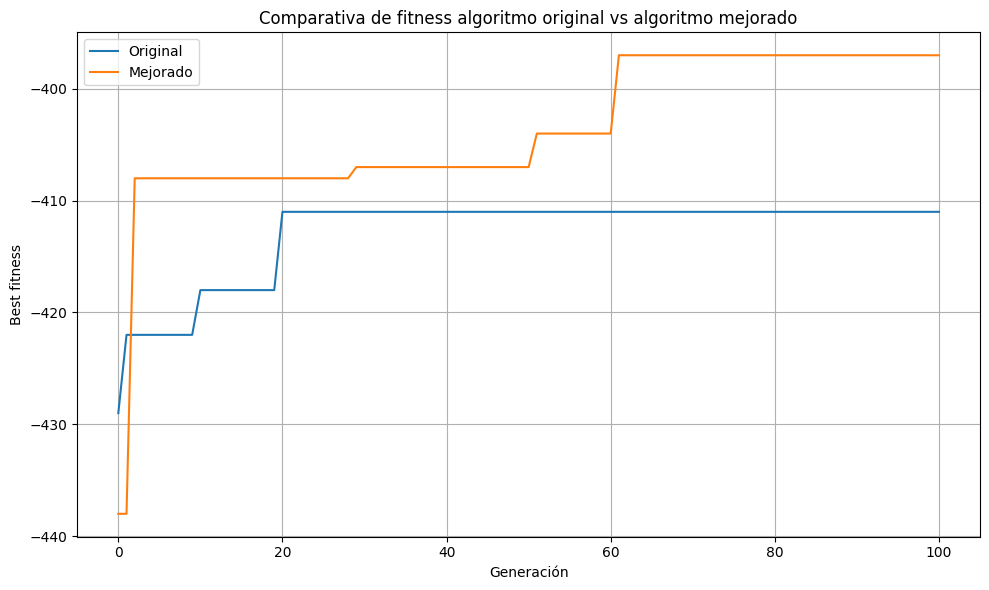


Resumen final:
Original | Mejor fitness: -411.0 | NFE final: 1010 | Tiempo final: 0.3064 segundos
Mejorado | Mejor fitness: -397.0 | NFE final: 3030 | Tiempo final: 0.7946 segundos
validacion de integridad:  True


In [6]:
def ejecutar_corrida(nombre, parametros):
    global NFE, start_time

    NFE = 0
    start_time = time.time()

    random.seed(parametros["semilla"])

    veryBest = None
    fitnessVeryBest = None

    mejores_por_generacion = []
    nfe_por_generacion = []
    tiempo_por_generacion = []

    poblacion = crear_poblacion_inicial(parametros["poblacion_inicial"])

    poblacion = mutar_poblacion_v2(
        poblacion,
        num_gaps=parametros["gaps_iniciales"]
    )

    poblacion = [igualar_longitud_secuencias(ind) for ind in poblacion]

    scores = [evaluar_individuo_blosum62(ind) for ind in poblacion]

    poblacion, scores = eliminar_peores(
        poblacion,
        scores,
        porcentaje=parametros["porcentaje_seleccion"]
    )

    best, fitness_best = obtener_best(scores, poblacion)

    veryBest = best
    fitnessVeryBest = fitness_best

    mejores_por_generacion.append(fitnessVeryBest)
    nfe_por_generacion.append(NFE)
    tiempo_por_generacion.append(time.time() - start_time)

    for generacion in range(1, parametros["generaciones"] + 1):

        poblacion = cruzar_poblacion_doble_punto(
            poblacion,
            p_cruce=parametros["p_cruce"],
            n_gaps_hijo=parametros["n_gaps_hijo"],
            p_mutacion=parametros["p_mutacion"]
        )

        poblacion = [igualar_longitud_secuencias(ind) for ind in poblacion]

        scores = [evaluar_individuo_blosum62(ind) for ind in poblacion]

        poblacion, scores = eliminar_peores(
            poblacion,
            scores,
            porcentaje=parametros["porcentaje_seleccion"]
        )

        best, fitness_best = obtener_best(scores, poblacion)

        if fitness_best > fitnessVeryBest:
            veryBest = best
            fitnessVeryBest = fitness_best

        mejores_por_generacion.append(fitnessVeryBest)
        nfe_por_generacion.append(NFE)
        tiempo_por_generacion.append(time.time() - start_time)

        print(
            nombre,
            "Generación:", generacion,
            "Fitness:", fitnessVeryBest,
            "NFE:", NFE,
            "Tiempo:", round(time.time() - start_time, 4)
        )

    return {
        "nombre": nombre,
        "mejores": mejores_por_generacion,
        "nfe": nfe_por_generacion,
        "tiempo": tiempo_por_generacion,
        "best": veryBest,
        "fitness_best": fitnessVeryBest
    }


if __name__ == "__main__":

    esquemas = {
    "Original": {
        "poblacion_inicial": 10,
        "generaciones": 100,
        "gaps_iniciales": 1,
        "p_cruce": 1.0,
        "p_mutacion": 0.8,
        "n_gaps_hijo": 1,
        "porcentaje_seleccion": 0.5,
        "semilla": 10
    },

    "Mejorado": {
        "poblacion_inicial": 30,
        "generaciones": 100,
        "gaps_iniciales": 2,
        "p_cruce": 0.85,
        "p_mutacion": 0.6,
        "n_gaps_hijo": 1,
        "porcentaje_seleccion": 0.5,
        "semilla": 10
        }
    }

    resultados = []

    for nombre, parametros in esquemas.items():
        resultado = ejecutar_corrida(nombre, parametros)
        resultados.append(resultado)

    plt.figure(figsize=(10, 6))

    for resultado in resultados:
        plt.plot(
            range(len(resultado["mejores"])),
            resultado["mejores"],
            label=resultado["nombre"]
        )

    plt.title("Comparativa de fitness algoritmo original vs algoritmo mejorado")
    plt.xlabel("Generación")
    plt.ylabel("Best fitness")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print("\nResumen final:")
    for resultado in resultados:
        print(
            resultado["nombre"],
            "| Mejor fitness:",
            resultado["fitness_best"],
            "| NFE final:",
            resultado["nfe"][-1],
            "| Tiempo final:",
            round(resultado["tiempo"][-1], 4),
            "segundos"
        )
    print ("validacion de integridad: ",validar_poblacion_sin_gaps(poblacion, get_sequences()))